## Analisis de Datos Exploratorio Bivariable (EDA)

### By:
Miguel Angel Toro Ramos

### Date:
2026-08-20

### Description:

Realizar un buen análisis de datos exploratorio (EDA) para caracterizar los datos disponibles para el proyecto.

## 📚 Import  libraries

In [22]:
# base libraries for data science
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.simplefilter(action="ignore", category=FutureWarning)

In [23]:
# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

In [24]:
# print library version for reproducibility

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
Pandas version:  3.0.5


## 💾 Load data

In [25]:
DATA_DIR = Path.cwd().resolve().parents[0] / "Admisiones-predict-project" / "data"

admisiones_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admisiones_type_fixed.parquet", engine="pyarrow"
)

In [26]:
admisiones_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          612 non-null    Int64  
 1   TOEFL Score        604 non-null    Int64  
 2   University Rating  617 non-null    Int64  
 3   SOP                607 non-null    float64
 4   LOR                615 non-null    float64
 5   CGPA               621 non-null    float64
 6   Research           594 non-null    boolean
 7   Chance of Admit    623 non-null    float64
dtypes: Int64(3), boolean(1), float64(4)
memory usage: 37.2 KB


## Exploración inicial de los datos

In [27]:
admisiones_df.shape

(623, 8)

In [28]:
# sample of the dataframe
admisiones_df.sample(10)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
408,<NA>,105,3,2.00,3.00,8.02,True,0.50
83,322,115,5,4.00,4.50,9.36,True,0.92
617,317,105,3,3.50,3.00,8.56,False,0.68
177,319,110,3,3.50,3.50,9.04,False,0.82
530,313,107,3,4.00,4.50,8.69,<NA>,0.72
550,312,104,3,3.50,3.50,8.42,False,0.74
65,325,112,4,3.50,3.50,8.92,False,0.55
606,321,112,5,5.00,5.00,9.06,True,0.86
94,303,99,3,2.00,2.50,7.66,False,0.36
62,304,105,2,3.00,3.00,8.20,True,0.54


In [29]:
admisiones_df.isnull().sum()

GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0
dtype: int64

## Numeric variables

In [30]:
admisiones_df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit
count,612.00,604.00,617.00,607.00,615.00,621.00,623.00
mean,317.09,107.87,3.18,3.46,3.52,8.64,0.73
std,11.75,6.12,1.15,1.01,0.87,0.59,0.14
min,290.00,92.00,1.00,1.00,1.00,6.80,0.34
25%,309.00,104.00,2.00,3.00,3.00,8.22,0.64
50%,317.00,108.00,3.00,3.50,3.50,8.65,0.73
75%,326.00,112.00,4.00,4.00,4.00,9.10,0.84
max,340.00,120.00,5.00,5.00,5.00,9.92,0.97


## Bool variables

In [32]:
# categorical columns description
admisiones_df.describe(include="bool")

,Research
count,594
unique,2
top,True
freq,327


## Analisis bivariable

Es importante realizar un analisis entre la variable objetivo y las variables predictoras, para determinar la relación entre ellas y poder seleccionar las variables más importantes para el modelo.

### Objetivo vs Variables numericas

In [33]:
# list of the numerical columns
numerical_columns = list(admisiones_df.select_dtypes(include=["number"]).columns)
numerical_columns.remove("Chance of Admit ")  # remove the target variable from the list
numerical_columns

['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA']

Pearson cuantifica la asociación lineal entre dos variables numéricas, mientras que Spearman cuantifica la asociación monotónica a partir de sus rangos. Compararlos permite detectar relaciones crecientes o decrecientes que no sean estrictamente lineales.

,predictor,n_observations,pearson_correlation,spearman_correlation,association_strength
0,GRE Score,612,0.821,0.834,muy fuerte
1,TOEFL Score,604,0.813,0.823,muy fuerte
2,University Rating,617,0.657,0.674,fuerte
3,SOP,607,0.647,0.668,fuerte
4,LOR,615,0.646,0.643,fuerte
5,CGPA,621,0.883,0.890,muy fuerte


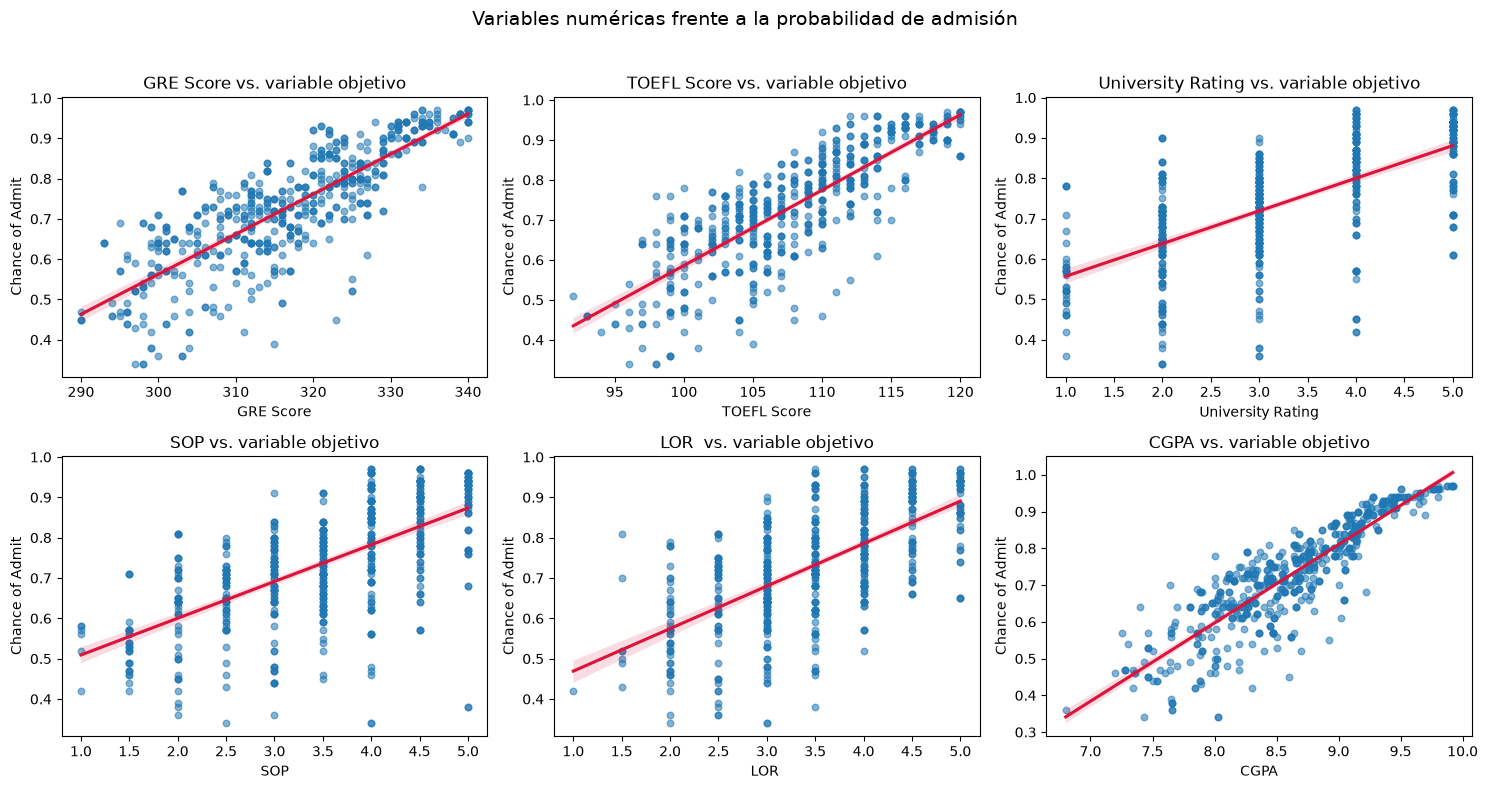

In [36]:
target_column = "Chance of Admit "
MINIMUM_OBSERVATIONS_FOR_PLOT = 2
VERY_WEAK_ASSOCIATION_LIMIT = 0.10
WEAK_ASSOCIATION_LIMIT = 0.30
MODERATE_ASSOCIATION_LIMIT = 0.50
STRONG_ASSOCIATION_LIMIT = 0.70


def categorizar_fuerza_asociacion(correlacion):
    if pd.isna(correlacion):
        return "no calculable"
    valor_absoluto = abs(correlacion)
    if valor_absoluto < VERY_WEAK_ASSOCIATION_LIMIT:
        return "muy débil"
    if valor_absoluto < WEAK_ASSOCIATION_LIMIT:
        return "débil"
    if valor_absoluto < MODERATE_ASSOCIATION_LIMIT:
        return "moderada"
    if valor_absoluto < STRONG_ASSOCIATION_LIMIT:
        return "fuerte"
    return "muy fuerte"


resultados_asociacion = []
for predictor in numerical_columns:
    pares_completos = admisiones_df[[predictor, target_column]].dropna()
    correlacion_pearson = pares_completos[predictor].corr(
        pares_completos[target_column], method="pearson"
    )
    correlacion_spearman = pares_completos[predictor].corr(
        pares_completos[target_column], method="spearman"
    )
    resultados_asociacion.append(
        {
            "predictor": predictor,
            "n_observations": len(pares_completos),
            "pearson_correlation": correlacion_pearson,
            "spearman_correlation": correlacion_spearman,
            "association_strength": categorizar_fuerza_asociacion(correlacion_pearson),
        }
    )

tabla_asociaciones = pd.DataFrame(resultados_asociacion)
display(
    tabla_asociaciones.style.format(
        {
            "pearson_correlation": "{:.3f}",
            "spearman_correlation": "{:.3f}",
        }
    )
)

n_columnas = min(3, len(numerical_columns))
n_filas = (len(numerical_columns) + n_columnas - 1) // n_columnas
figura, ejes = plt.subplots(
    n_filas, n_columnas, figsize=(5 * n_columnas, 4 * n_filas), squeeze=False
)

for eje, predictor in zip(ejes.flat, numerical_columns, strict=False):
    pares_completos = admisiones_df[[predictor, target_column]].dropna()
    if (
        len(pares_completos) >= MINIMUM_OBSERVATIONS_FOR_PLOT
        and pares_completos[predictor].nunique() > 1
    ):
        sns.regplot(
            data=pares_completos,
            x=predictor,
            y=target_column,
            ax=eje,
            scatter_kws={"alpha": 0.55, "s": 22},
            line_kws={"color": "crimson"},
        )
    else:
        eje.text(0.5, 0.5, "Observaciones insuficientes", ha="center", va="center")
    eje.set_title(f"{predictor} vs. variable objetivo")
    eje.set_xlabel(predictor)
    eje.set_ylabel(target_column.strip())

for eje in ejes.flat[len(numerical_columns) :]:
    eje.remove()

figura.suptitle("Variables numéricas frente a la probabilidad de admisión", fontsize=14)
figura.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

**Interpretación y cautelas.** La correlación indica asociación, no causalidad, y una correlación lineal puede no captar efectos no lineales. `University Rating`, `SOP` y `LOR` son escalas ordinales y acotadas; por ello, Spearman es especialmente informativo. Este EDA no realiza selección de variables por sí mismo: esa decisión requiere validación posterior en el contexto del modelo.

### Objetivo vs Variables categoricas

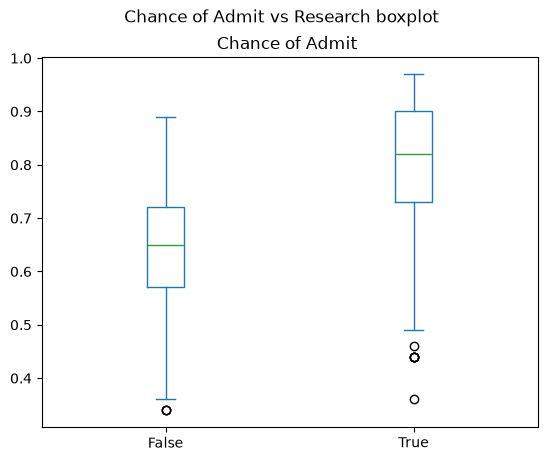

In [37]:
objetivo = "Chance of Admit "
columna = "Research"
admisiones_df.plot(
    kind="box",
    column=objetivo,
    by=columna,
    grid=False,
    title="Chance of Admit vs Research boxplot",
);

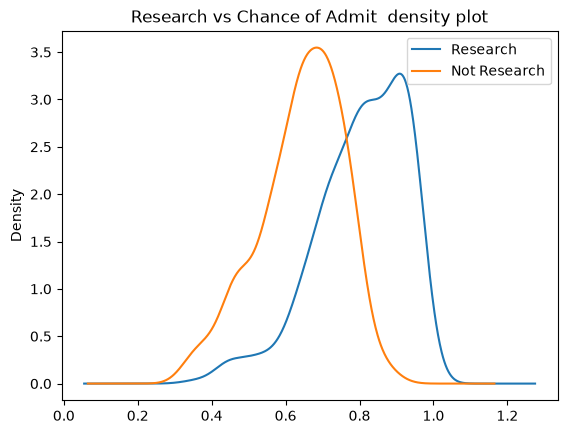

In [38]:
admisiones_df[admisiones_df[columna] == 1][objetivo].plot(
    kind="kde",
    label="Research",
    legend=True,
    title=f"{columna} vs {objetivo} density plot",
)
admisiones_df[admisiones_df[columna] == 0][objetivo].plot(
    kind="kde",
    label="Not Research",
    legend=True,
    xlabel=objetivo,
    ylabel="Density",
);

## Numerical vs Numerical Variables

**Interpretación y cautela.** Una alta correlación entre predictores puede indicar redundancia o multicolinealidad, pero no justifica eliminar variables durante el EDA; debe confirmarse mediante validación y diagnósticos del modelo. Spearman es especialmente útil para las variables ordinales `University Rating`, `SOP` y `LOR`, porque evalúa asociaciones monotónicas a partir de rangos.

,predictor_1,predictor_2,pearson,spearman,fuerza_asociacion
0,GRE Score,TOEFL Score,0.846,0.846,muy fuerte
4,GRE Score,CGPA,0.843,0.843,muy fuerte
8,TOEFL Score,CGPA,0.843,0.845,muy fuerte
12,SOP,LOR,0.740,0.741,muy fuerte
11,University Rating,CGPA,0.706,0.715,muy fuerte
13,SOP,CGPA,0.699,0.710,fuerte
9,University Rating,SOP,0.679,0.681,fuerte
5,TOEFL Score,University Rating,0.649,0.645,fuerte
14,LOR,CGPA,0.648,0.649,fuerte
10,University Rating,LOR,0.646,0.639,fuerte


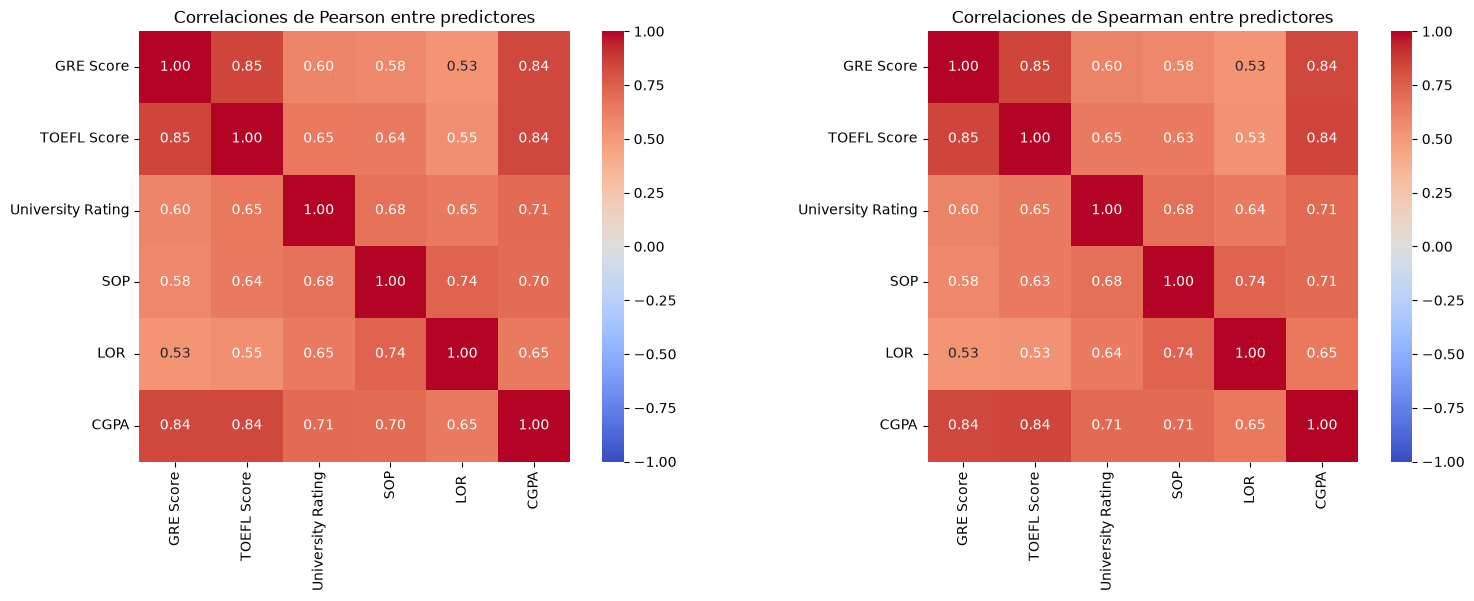

In [ ]:
correlaciones_pearson = admisiones_df[numerical_columns].corr(method="pearson")
correlaciones_spearman = admisiones_df[numerical_columns].corr(method="spearman")

pares_predictoras = [
    {
        "predictor_1": predictor_1,
        "predictor_2": predictor_2,
        "pearson": correlaciones_pearson.loc[predictor_1, predictor_2],
        "spearman": correlaciones_spearman.loc[predictor_1, predictor_2],
        "fuerza_asociacion": categorizar_fuerza_asociacion(
            correlaciones_pearson.loc[predictor_1, predictor_2]
        ),
    }
    for indice, predictor_1 in enumerate(numerical_columns)
    for predictor_2 in numerical_columns[indice + 1 :]
]

tabla_pares_fuertes = (
    pd.DataFrame(
        pares_predictoras,
        columns=[
            "predictor_1",
            "predictor_2",
            "pearson",
            "spearman",
            "fuerza_asociacion",
        ],
    )
    .assign(asociacion_absoluta=lambda tabla: tabla["pearson"].abs())
    .sort_values("asociacion_absoluta", ascending=False)
    .drop(columns="asociacion_absoluta")
    .head(10)
)
display(tabla_pares_fuertes.style.format({"pearson": "{:.3f}", "spearman": "{:.3f}"}))

figura, ejes = plt.subplots(1, 2, figsize=(16, 6))
for eje, correlaciones, titulo in zip(
    ejes,
    (correlaciones_pearson, correlaciones_spearman),
    (
        "Correlaciones de Pearson entre predictores",
        "Correlaciones de Spearman entre predictores",
    ),
    strict=True,
):
    sns.heatmap(
        correlaciones,
        ax=eje,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
    )
    eje.set_title(titulo)

figura.tight_layout()
plt.show()

## Numerical vs Categorical Variables

Esta sección compara la distribución de los predictores numéricos contenidos en `numerical_columns` (que ya excluye la variable objetivo) entre los grupos de `Research`. Las filas con `Research` faltante se excluyen únicamente de esta comparación y no se tratan como `False`.

In [41]:
# Se excluyen solo los valores faltantes de Research para esta comparación.
datos_por_research = admisiones_df.dropna(subset=["Research"])

resumen_por_research = []
for predictor in numerical_columns:
    for research, grupo in datos_por_research.groupby("Research", observed=True):
        valores_completos = grupo[predictor].dropna()
        resumen_por_research.append(
            {
                "numeric_predictor": predictor,
                "Research_group": research,
                "n_observations": valores_completos.size,
                "mean": valores_completos.mean(),
                "median": valores_completos.median(),
                "standard_deviation": valores_completos.std(),
                "missing_value_count": grupo[predictor].isna().sum(),
            }
        )

tabla_resumen_research = pd.DataFrame(resumen_por_research)
display(
    tabla_resumen_research.style.format(
        {
            "mean": "{:.2f}",
            "median": "{:.2f}",
            "standard_deviation": "{:.2f}",
        }
    )
)

,numeric_predictor,Research_group,n_observations,mean,median,standard_deviation,missing_value_count
0,GRE Score,False,263,309.44,310.00,8.70,4
1,GRE Score,True,322,323.35,324.00,10.08,5
2,TOEFL Score,False,253,104.29,105.00,4.56,14
3,TOEFL Score,True,323,110.57,111.00,5.77,4
4,University Rating,False,264,2.65,3.00,1.04,3
5,University Rating,True,327,3.59,4.00,1.08,0
6,SOP,False,260,2.97,3.00,0.99,7
7,SOP,True,320,3.83,4.00,0.86,7
8,LOR,False,264,3.12,3.00,0.80,3
9,LOR,True,323,3.82,4.00,0.79,4


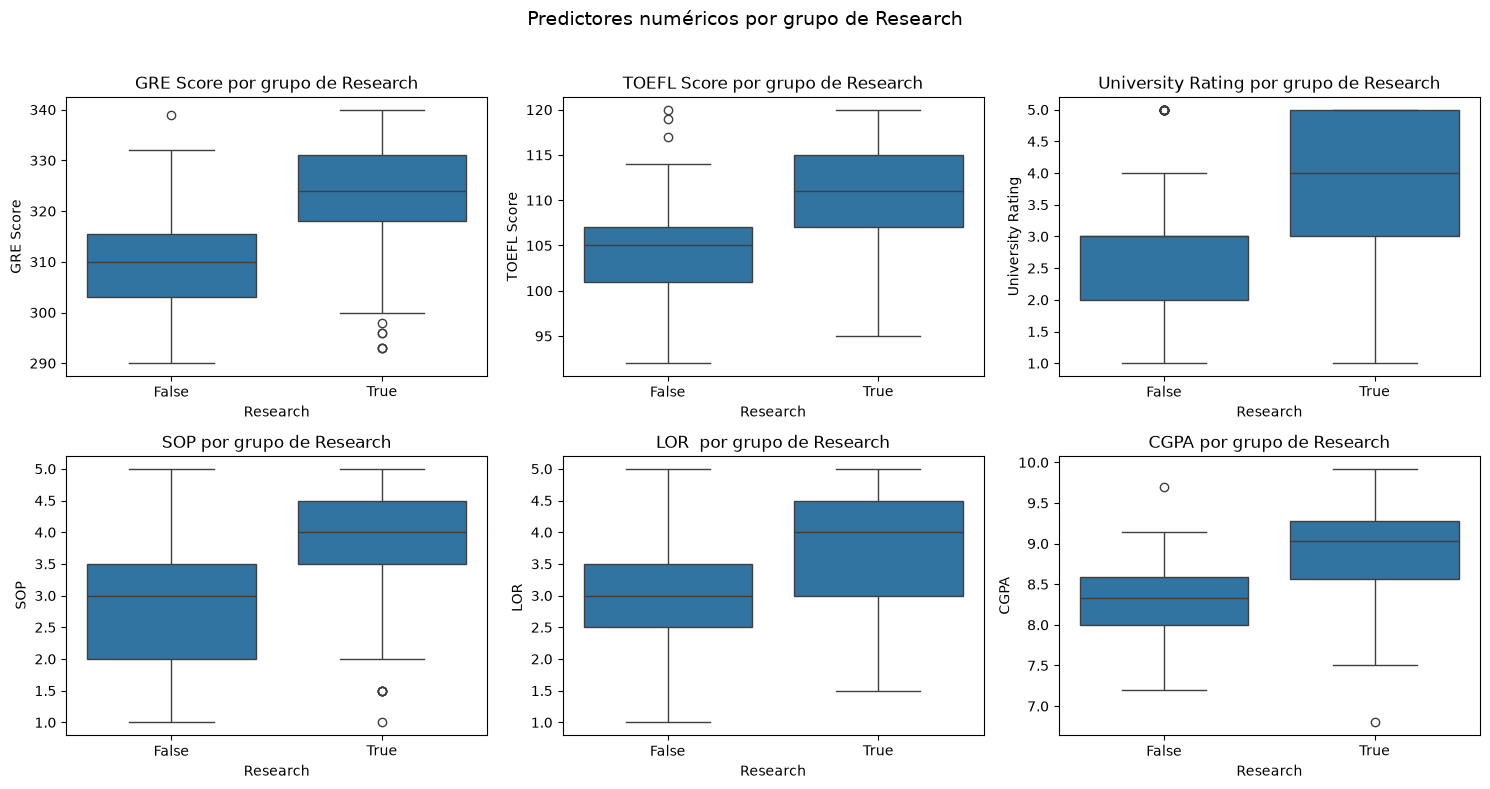

In [43]:
# La misma exclusión explícita se aplica antes de construir los gráficos.
datos_por_research = admisiones_df.dropna(subset=["Research"])
n_columnas = min(3, len(numerical_columns))
n_filas = (len(numerical_columns) + n_columnas - 1) // n_columnas
figura, ejes = plt.subplots(
    n_filas, n_columnas, figsize=(5 * n_columnas, 4 * n_filas), squeeze=False
)

for eje, predictor in zip(ejes.flat, numerical_columns, strict=False):
    sns.boxplot(
        data=datos_por_research,
        x="Research",
        y=predictor,
        order=[False, True],
        ax=eje,
    )
    eje.set_title(f"{predictor} por grupo de Research")
    eje.set_xlabel("Research")
    eje.set_ylabel(predictor)

for eje in ejes.flat[len(numerical_columns) :]:
    eje.remove()

figura.suptitle("Predictores numéricos por grupo de Research", fontsize=14)
figura.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

**Cautela.** Las diferencias entre grupos son descriptivas; deben considerarse los tamaños desiguales de los grupos y los valores faltantes. `Research` puede estar asociado con otros predictores, por lo que este análisis no permite establecer efectos causales ni identificar su contribución independiente.

## 📊 Analysis of Results and Conclusions 

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work


### Conclusiones

- **Asociaciones con el objetivo.** `CGPA` presenta la asociación lineal más alta con `Chance of Admit` (Pearson = 0.883), seguida de `GRE Score` (0.821) y `TOEFL Score` (0.813); estas asociaciones no implican causalidad.
- **Research.** La comparación por grupos es descriptiva y sus filas con valores faltantes se excluyen solo de ese contraste; las salidas almacenadas no incluyen una medida numérica del objetivo por grupo, por lo que no se extrae una conclusión direccional independiente.
- **Redundancia potencial.** `GRE Score`, `TOEFL Score` y `CGPA` están fuertemente correlacionados entre sí (Pearson = 0.846, 0.843 y 0.843); esto sugiere posible redundancia o multicolinealidad que debe evaluarse en el modelo.
- **Preparación y validación.** Antes de modelar, se debe definir el tratamiento de los faltantes (por ejemplo, imputación dentro de cada partición de entrenamiento) y validar modelos con particiones o validación cruzada, comparando conjuntos de predictores y diagnósticos de colinealidad.
- **Alcance.** Este EDA identifica patrones descriptivos, pero no demuestra utilidad predictiva, contribución independiente de las variables ni relaciones causales; esas conclusiones requieren evaluación fuera de muestra.